# Rice Diseases are classified using CNN with Tensorflow

In [5]:
# import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf

In [6]:
import pandas as pd

data = pd.read_csv(r"C:\Projects\python_for_data_science\00_projects\04_rice_dieases_classification\data\train.csv")
data.head()

,image_id,label,variety,age
0,100330.jpg,bacterial_leaf_blight,ADT45,45
1,100365.jpg,bacterial_leaf_blight,ADT45,45
2,100382.jpg,bacterial_leaf_blight,ADT45,45
3,100632.jpg,bacterial_leaf_blight,ADT45,45
4,101918.jpg,bacterial_leaf_blight,ADT45,45


In [7]:
# check the shape of data
data.shape

(10407, 4)

In [8]:
data['label'].unique().tolist()

['bacterial_leaf_blight',
 'bacterial_leaf_streak',
 'bacterial_panicle_blight',
 'blast',
 'brown_spot',
 'dead_heart',
 'downy_mildew',
 'hispa',
 'normal',
 'tungro']

In [9]:
data['variety'].unique().tolist()

['ADT45',
 'IR20',
 'KarnatakaPonni',
 'Onthanel',
 'Ponni',
 'Surya',
 'Zonal',
 'AndraPonni',
 'AtchayaPonni',
 'RR']

In [10]:
data['age'].describe()

count    10407.000000
mean        64.043624
std          8.958830
min         45.000000
25%         60.000000
50%         67.000000
75%         70.000000
max         82.000000
Name: age, dtype: float64

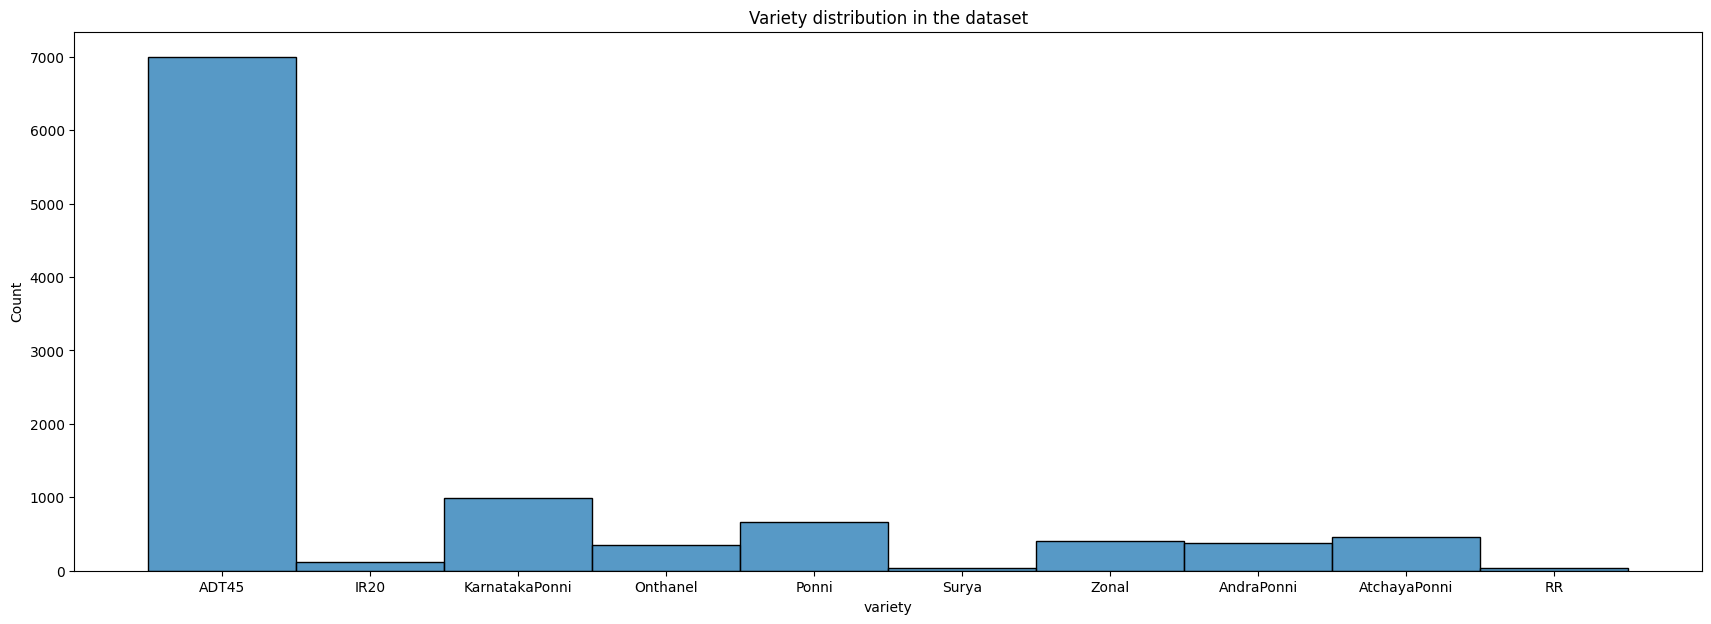

In [11]:
# plot the data count based on variety name
fig,axes = plt.subplots(1,1,figsize=(21,7))
sns.histplot(data,x='variety',ax=axes)
plt.title('Variety distribution in the dataset')
plt.show()

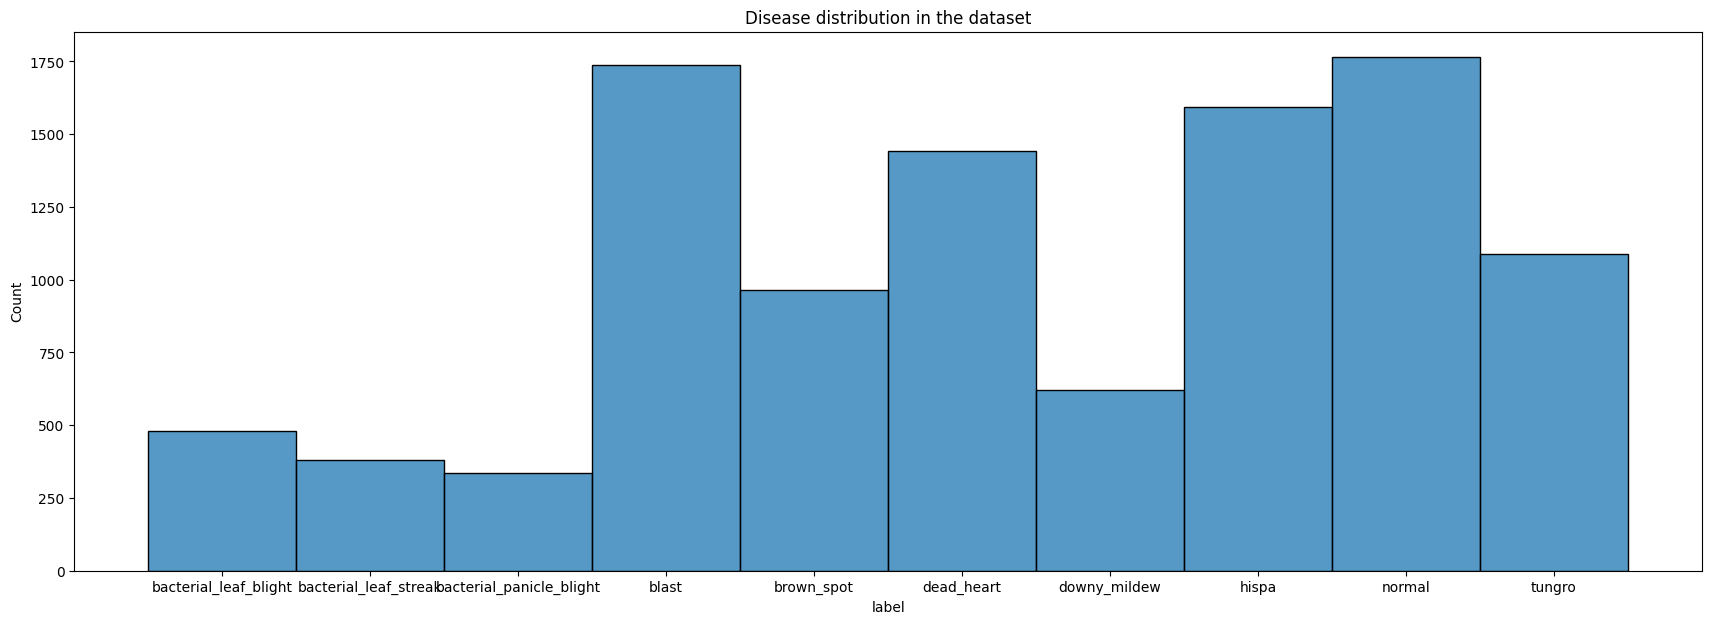

In [12]:
# plot the data count based on variety name
fig,axes = plt.subplots(1,1,figsize=(21,7))
sns.histplot(data,x='label',ax=axes)
plt.title('Disease distribution in the dataset')
plt.show()

In [13]:
normal = data[data['label'] =='normal']
normal = normal[normal['variety'] =='ADT45']
five_normals = normal.image_id[:5].values
five_normals.tolist()

['100007.jpg', '100025.jpg', '100135.jpg', '100165.jpg', '100171.jpg']

In [14]:
dead = data[data['label'] =='dead_heart']
dead = dead[dead['variety'] =='ADT45']
five_deads= dead.image_id[:5].values
five_deads.tolist()

['101165.jpg', '102750.jpg', '108367.jpg', '109900.jpg', '100222.jpg']

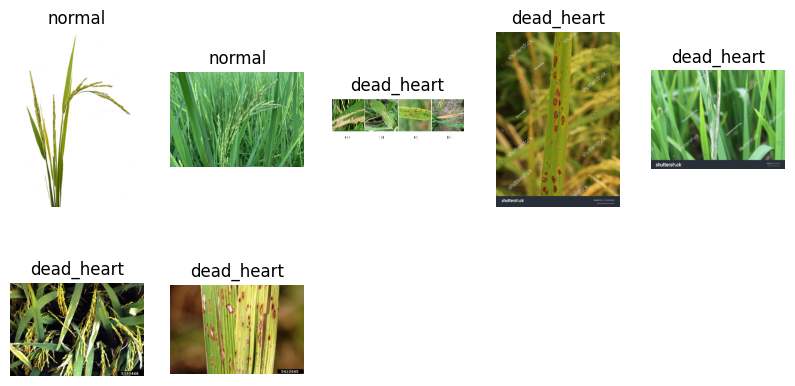

In [39]:
import matplotlib.pyplot as plt
import os

path = r'c:\Projects\python_for_data_science\00_projects\04_rice_dieases_classification\data\train_images\\'

normal = os.listdir(path + "normal")
dead = os.listdir(path + "dead_heart")

plt.figure(figsize=(10,5))

# take safe number of images
n = min(5, len(normal))
d = min(5, len(dead))

for i in range(n + d):
    plt.subplot(2,5,i+1)

    if i < n:
        img = plt.imread(path + "normal/" + normal[i])
        plt.title("normal")
    else:
        img = plt.imread(path + "dead_heart/" + dead[i - n])
        plt.title("dead_heart")

    plt.imshow(img)
    plt.axis('off')

plt.show()

Missing: c:\Projects\python_for_data_science\00_projects\04_rice_dieases_classification\data\train_images\\hispa/106590.jpg
Missing: c:\Projects\python_for_data_science\00_projects\04_rice_dieases_classification\data\train_images\\tungro/109629.jpg
Missing: c:\Projects\python_for_data_science\00_projects\04_rice_dieases_classification\data\train_images\\bacterial_leaf_blight/109372.jpg
Missing: c:\Projects\python_for_data_science\00_projects\04_rice_dieases_classification\data\train_images\\downy_mildew/102350.jpg
Missing: c:\Projects\python_for_data_science\00_projects\04_rice_dieases_classification\data\train_images\\blast/110243.jpg
Missing: c:\Projects\python_for_data_science\00_projects\04_rice_dieases_classification\data\train_images\\bacterial_leaf_streak/101104.jpg
Missing: c:\Projects\python_for_data_science\00_projects\04_rice_dieases_classification\data\train_images\\normal/109760.jpg
Missing: c:\Projects\python_for_data_science\00_projects\04_rice_dieases_classification\dat

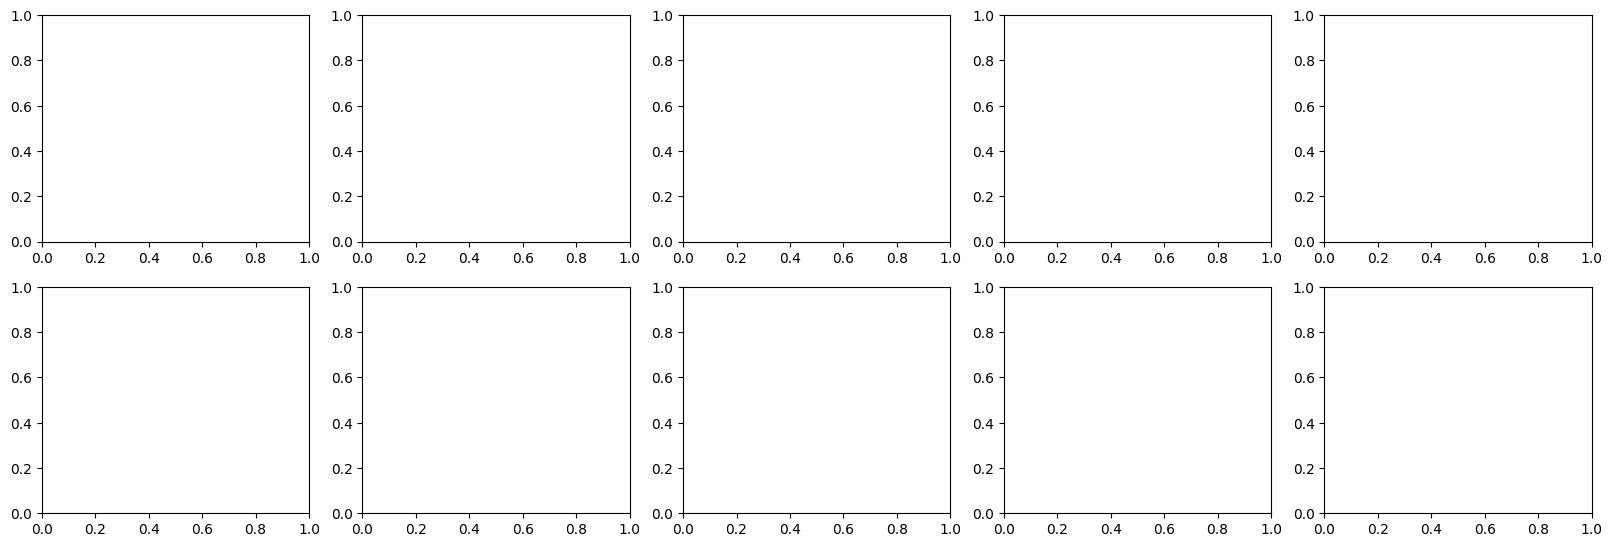

In [41]:
import matplotlib.pyplot as plt
import os

# ✅ Correct base path
base_path = r'c:\Projects\python_for_data_science\00_projects\04_rice_dieases_classification\data\train_images\\'

# ❌ your old relative paths → we will auto-fix them
images = [
    './data/train_images/hispa/106590.jpg',
    './data/train_images/tungro/109629.jpg',
    './data/train_images/bacterial_leaf_blight/109372.jpg',
    './data/train_images/downy_mildew/102350.jpg',
    './data/train_images/blast/110243.jpg',
    './data/train_images/bacterial_leaf_streak/101104.jpg',
    './data/train_images/normal/109760.jpg',
    './data/train_images/brown_spot/104675.jpg',
    './data/train_images/dead_heart/105159.jpg',
    './data/train_images/bacterial_panicle_blight/101351.jpg',
]

# ✅ AUTO-FIX PATHS (IMPORTANT LINE)
images = [os.path.join(base_path, img.replace('./data/train_images/', '')) for img in images]

# labels
diseases = ['hispa','tungro','bacterial_leaf_blight','downy_mildew','blast',
            'bacterial_leaf_streak','normal','brown_spot','dead_heart','bacterial_panicle_blight']

diseases = [d + ' image' for d in diseases]

# plot
plt.figure(figsize=(20,10))
columns = 5

for i, image_loc in enumerate(images):
    plt.subplot(len(images)//columns + 1, columns, i + 1)

    # ✅ safety check (prevents crash)
    if not os.path.exists(image_loc):
        print("Missing:", image_loc)
        continue

    image = plt.imread(image_loc)
    plt.title(diseases[i])
    plt.imshow(image)
    plt.axis('off')

plt.show()

In [17]:
data.head()

,image_id,label,variety,age
0,100330.jpg,bacterial_leaf_blight,ADT45,45
1,100365.jpg,bacterial_leaf_blight,ADT45,45
2,100382.jpg,bacterial_leaf_blight,ADT45,45
3,100632.jpg,bacterial_leaf_blight,ADT45,45
4,101918.jpg,bacterial_leaf_blight,ADT45,45


In [18]:
# encode both columns label and variety
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
data['label'] = label_encoder.fit_transform(data['label'])
data['variety'] = label_encoder.fit_transform(data['variety'])

data.head()

,image_id,label,variety,age
0,100330.jpg,0,0,45
1,100365.jpg,0,0,45
2,100382.jpg,0,0,45
3,100632.jpg,0,0,45
4,101918.jpg,0,0,45


In [19]:
# define parameter
batch_size = 32
img_height = 224
img_width = 224

In [42]:
train_ds = tf.keras.utils.image_dataset_from_directory(
  path,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 8 files belonging to 2 classes.
Using 7 files for training.


In [44]:
import os
import tensorflow as tf

path = r"c:\Projects\python_for_data_science\00_projects\04_rice_dieases_classification\data\train_images"

val_ds = tf.keras.utils.image_dataset_from_directory(
    path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

Found 8 files belonging to 2 classes.
Using 1 files for validation.


In [45]:
class_names = train_ds.class_names
print(class_names)

['dead_heart', 'normal']


In [46]:
for image_batch, labels_batch in train_ds:
  print(image_batch.shape)
  print(labels_batch.shape)
  break

(7, 224, 224, 3)
(7,)


In [24]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

In [47]:
normalized_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
image_batch, labels_batch = next(iter(normalized_ds))
first_image = image_batch[0]
# Notice the pixel values are now in `[0,1]`.
print(np.min(first_image), np.max(first_image))

0.0 1.0


In [48]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [49]:
num_classes = len(class_names)
num_classes

2

In [50]:
model = tf.keras.Sequential([
  tf.keras.layers.Rescaling(1./255),
  tf.keras.layers.Conv2D(128, 3, activation='relu'),
  tf.keras.layers.MaxPooling2D(),
  tf.keras.layers.Conv2D(64, 3, activation='relu'),
  tf.keras.layers.MaxPooling2D(),
  tf.keras.layers.Conv2D(32, 3, activation='relu'),
  tf.keras.layers.MaxPooling2D(),
  tf.keras.layers.Conv2D(16, 3, activation='relu'),
  tf.keras.layers.MaxPooling2D(),
  tf.keras.layers.Flatten(),
  tf.keras.layers.Dropout(0.25),
  tf.keras.layers.Dense(128, activation='relu'),
  tf.keras.layers.Dense(num_classes, activation='softmax')
])

In [51]:
model.compile(
  optimizer='adam',
  loss=tf.losses.SparseCategoricalCrossentropy(from_logits=True),
  metrics=['accuracy'])

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step - accuracy: 0.4286 - loss: 0.6995 - val_accuracy: 0.0000e+00 - val_loss: 1.9069
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.8571 - loss: 0.3955 - val_accuracy: 0.0000e+00 - val_loss: 6.6621
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.8571 - loss: 0.5342 - val_accuracy: 0.0000e+00 - val_loss: 5.0411
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - accuracy: 0.8571 - loss: 0.4044 - val_accuracy: 0.0000e+00 - val_loss: 2.6999
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.8571 - loss: 0.3191 - val_accuracy: 0.0000e+00 - val_loss: 1.7537
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.8571 - loss: 0.3754 - val_accuracy: 0.0000e+00 - val_loss: 1.7763
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.8571 - loss: 0.3555 - val_accuracy: 0.0000e+00 - val_loss: 2.4072
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.8571 - loss: 0.3317 - val_accuracy: 0.00

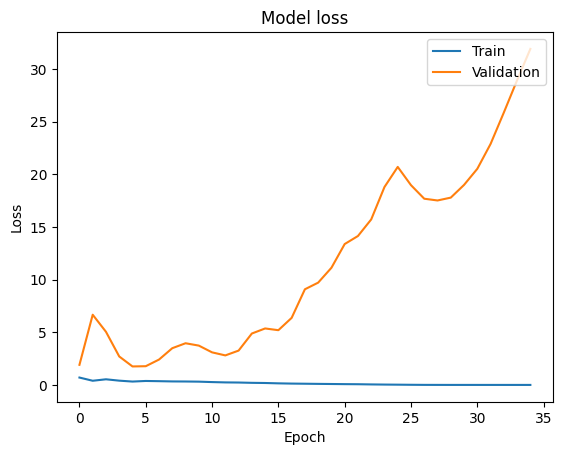

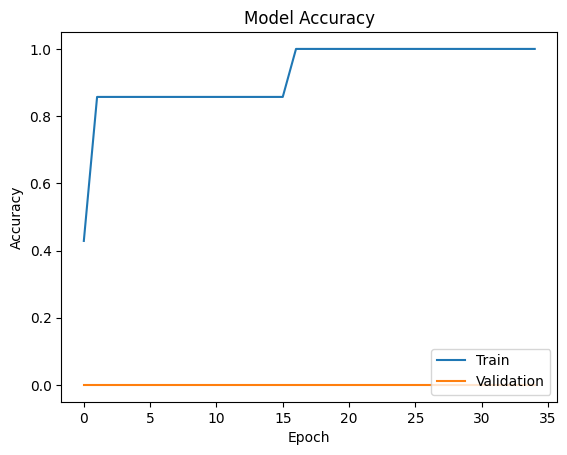

CPU times: total: 2min 28s
Wall time: 1min 34s


In [52]:
%%time
#remove warnings
import warnings
warnings.filterwarnings('ignore')

from tensorflow.keras.callbacks import EarlyStopping
# Define the callback function
early_stopping = EarlyStopping(patience=30)

history= model.fit(train_ds,
          validation_data=val_ds,
          epochs=100,
          callbacks=[early_stopping])

# evaluat the model
loss = model.evaluate(val_ds)

# Plotting the training and testing loss
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')
plt.show()

# plot the accuracy of training and validation

# Plotting the training and validation accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='lower right')
plt.show()

## Observations:
1. We have 10407, images in train data.
2. We have 10 unique disease classes.
3. We also have 10 variesites of RICE in this data.
4. We have rice plant age ranging from 45 - 85 days.
5. ADT45 is the most common variety inside the training data.